# **7-Day Data Camp - Final project**

## Part 2 - Data Exploration using Python

Import libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

Task 5: Load the dataset into Python

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving file1.csv to file1.csv


In [ ]:
df = pd.read_csv("file1.csv")
df.head()

,Order_Date,Country,City,Category,Sub_Category,Segment,Sales_Channel,Payment_Mode,Sales,Quantity,Discount,Profit
0,2022-06-20,UAE,Dubai,Furniture,Snacks,Consumer,Offline,UPI,2555.49,11,0.08,255.37
1,2023-12-05,UK,London,Sports,Phones,Home Office,Online,Net Banking,1795.27,9,0.28,-332.23
2,2022-07-05,USA,Los Angeles,Electronics,Shirts,Consumer,Offline,UPI,4554.73,10,0.13,140.24
3,2024-10-05,USA,New York,Furniture,Phones,Consumer,Online,Net Banking,3107.15,13,0.14,60.70
4,2023-07-21,USA,New York,Beauty,Fitness,Consumer,Offline,Card,2781.45,12,0.20,61.78


Task 6: Perform
- Dataset structire analysis → shape, columns and info to get the basic information about the dataset
  - shape: (rows, columns)
  - columns: name of columns
  - info: type of datum, number of rows, number of missing data

In [ ]:
df.shape

(1600, 12)

In [ ]:
df.columns

Index(['Order_Date', 'Country', 'City', 'Category', 'Sub_Category', 'Segment',
       'Sales_Channel', 'Payment_Mode', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_Date     1600 non-null   object 
 1   Country        1600 non-null   object 
 2   City           1600 non-null   object 
 3   Category       1600 non-null   object 
 4   Sub_Category   1600 non-null   object 
 5   Segment        1600 non-null   object 
 6   Sales_Channel  1600 non-null   object 
 7   Payment_Mode   1600 non-null   object 
 8   Sales          1600 non-null   float64
 9   Quantity       1600 non-null   int64  
 10  Discount       1600 non-null   float64
 11  Profit         1600 non-null   float64
dtypes: float64(3), int64(1), object(8)
memory usage: 150.1+ KB


- Summary statistics
  - describe, to get basic statistics about the numerical columns;
  - value_counts, to get unique values for categorical columns

In [ ]:
df.describe()

,Sales,Quantity,Discount,Profit
count,1600.000000,1600.000000,1600.000000,1600.000000
mean,2527.242200,7.582500,0.147138,244.332881
std,1410.954469,3.999618,0.085156,515.339896
min,100.260000,1.000000,0.000000,-937.750000
25%,1293.730000,4.000000,0.070000,-88.145000
50%,2496.750000,8.000000,0.150000,138.665000
75%,3715.987500,11.000000,0.220000,535.817500
max,4996.120000,14.000000,0.300000,1921.420000


In [ ]:
df[['Country', 'City']].value_counts().sort_index(ascending=True)

Country    City       
Australia  Melbourne      67
           Perth          66
           Sydney         76
Canada     Montreal       79
           Toronto        76
           Vancouver      61
France     Lyon           58
           Nice           70
           Paris          68
Germany    Berlin         67
           Hamburg        48
           Munich         57
India      Bangalore      75
           Delhi          63
           Mumbai         89
UAE        Abu Dhabi      61
           Dubai          71
           Sharjah        79
UK         Birmingham     49
           London         69
           Manchester     56
USA        Chicago        69
           Los Angeles    60
           New York       66
Name: count, dtype: int64

In [ ]:
df[['Category', 'Sub_Category']].value_counts().sort_index(ascending=False)

Category     Sub_Category
Sports       Snacks          41
             Shirts          50
             Phones          46
             Fitness         45
             Cosmetics       43
             Chairs          51
Groceries    Snacks          42
             Shirts          42
             Phones          37
             Fitness         45
             Cosmetics       48
             Chairs          54
Furniture    Snacks          41
             Shirts          33
             Phones          56
             Fitness         31
             Cosmetics       48
             Chairs          33
Electronics  Snacks          47
             Shirts          53
             Phones          44
             Fitness         44
             Cosmetics       46
             Chairs          54
Clothing     Snacks          48
             Shirts          37
             Phones          40
             Fitness         36
             Cosmetics       43
             Chairs          55
Beauty       Snacks          37
             Shirts          44
             Phones          54
             Fitness         41
             Cosmetics       43
             Chairs          48
Name: count, dtype: int64

In [ ]:
df[['Segment', 'Sales_Channel', 'Payment_Mode']].value_counts().sort_index(ascending=True)

Segment      Sales_Channel  Payment_Mode
Consumer     Offline        Card            82
                            Cash            57
                            Net Banking     64
                            UPI             71
             Online         Card            64
                            Cash            53
                            Net Banking     73
                            UPI             55
Corporate    Offline        Card            66
                            Cash            63
                            Net Banking     66
                            UPI             65
             Online         Card            74
                            Cash            58
                            Net Banking     69
                            UPI             74
Home Office  Offline        Card            75
                            Cash            72
                            Net Banking     58
                            UPI             78
             Online         Card            77
                            Cash            59
                            Net Banking     64
                            UPI             63
Name: count, dtype: int64

- Missing value check → isnull, to get the number of missing values

In [ ]:
df.isnull().sum()

,0
Order_Date,0
Country,0
City,0
Category,0
Sub_Category,0
Segment,0
Sales_Channel,0
Payment_Mode,0
Sales,0
Quantity,0


- Duplicate detection → duplicated, to get the number of duplicated rows

In [ ]:
df.duplicated().sum()

np.int64(0)

Task 7 - Analyse
- Distribution of key variavles
- Relationships between variables

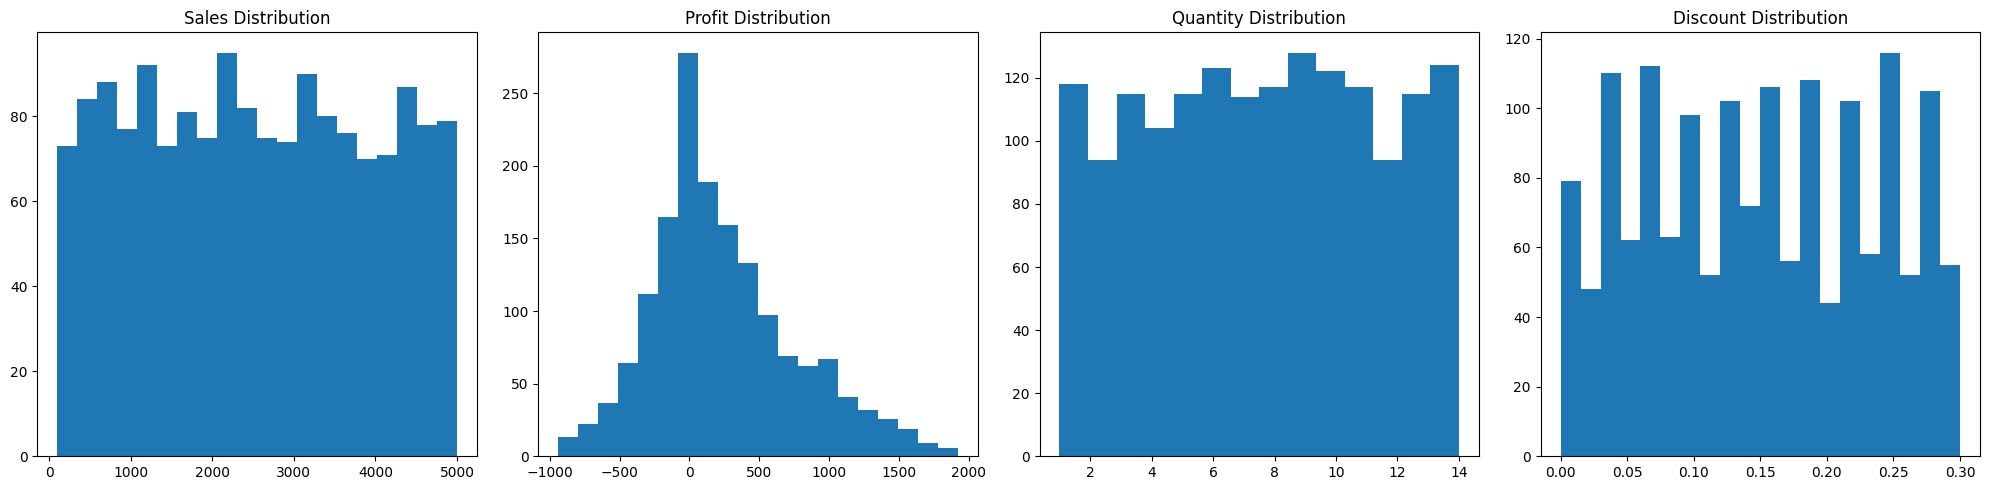

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20,5))
axes = axes.flatten()

# Sales
axes[0].hist(df['Sales'], bins=20)
axes[0].set_title("Sales Distribution")

# Profit
axes[1].hist(df['Profit'], bins=20)
axes[1].set_title("Profit Distribution")

# Quantity
axes[2].hist(df['Quantity'], bins=14)
axes[2].set_title("Quantity Distribution")

# Discount
axes[3].hist(df['Discount'], bins=20)
axes[3].set_title("Discount Distribution")

plt.tight_layout()
plt.show()

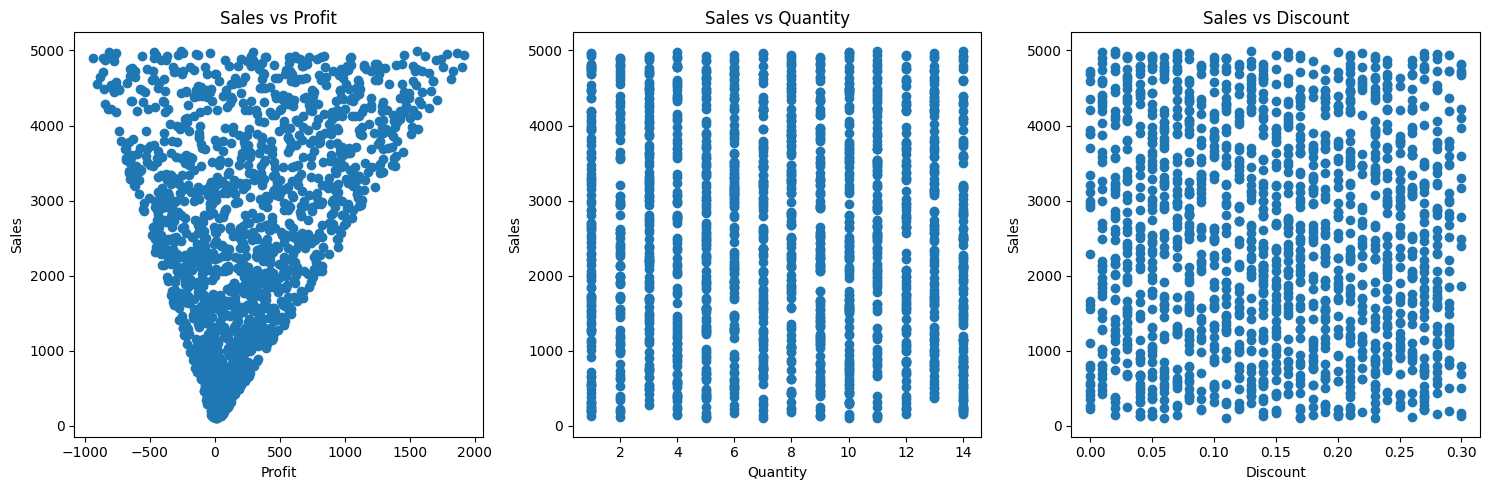

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
axes = axes.flatten()

# Sales vs Profit
axes[0].scatter(df['Profit'], df['Sales'])
axes[0].set_title("Sales vs Profit")
axes[0].set_xlabel("Profit")
axes[0].set_ylabel("Sales")

# Sales vs Quantity
axes[1].scatter(df['Quantity'], df['Sales'])
axes[1].set_title("Sales vs Quantity")
axes[1].set_xlabel("Quantity")
axes[1].set_ylabel("Sales")

# Sales vs Discount
axes[2].scatter(df['Discount'], df['Sales'])
axes[2].set_title("Sales vs Discount")
axes[2].set_xlabel("Discount")
axes[2].set_ylabel("Sales")

plt.tight_layout()
plt.show()

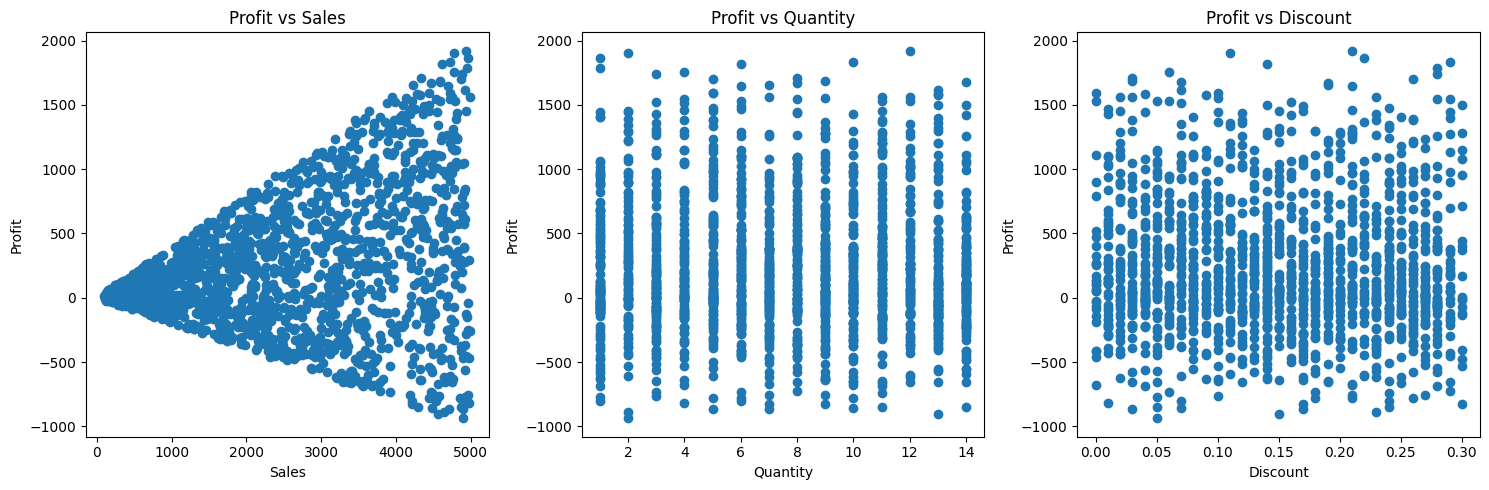

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
axes = axes.flatten()

# Profit vs Sales
axes[0].scatter(df['Sales'], df['Profit'])
axes[0].set_title("Profit vs Sales")
axes[0].set_xlabel("Sales")
axes[0].set_ylabel("Profit")

# Profit vs Sales
axes[1].scatter(df['Quantity'], df['Profit'])
axes[1].set_title("Profit vs Quantity")
axes[1].set_xlabel("Quantity")
axes[1].set_ylabel("Profit")

# Profit vs Sales
axes[2].scatter(df['Discount'], df['Profit'])
axes[2].set_title("Profit vs Discount")
axes[2].set_xlabel("Discount")
axes[2].set_ylabel("Profit")

plt.tight_layout()
plt.show()

Quantity and Discount seems not correlated with Profit and Sales as there is no trend in the scatterplots.

Before proceeding with the predictive analysis, I decided to include the Order_Date feature to eventually improve the ML models if trends are present.
To do so, I converted the column into a date format and created some additional columns.

In [ ]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month
df['Day'] = df['Order_Date'].dt.day

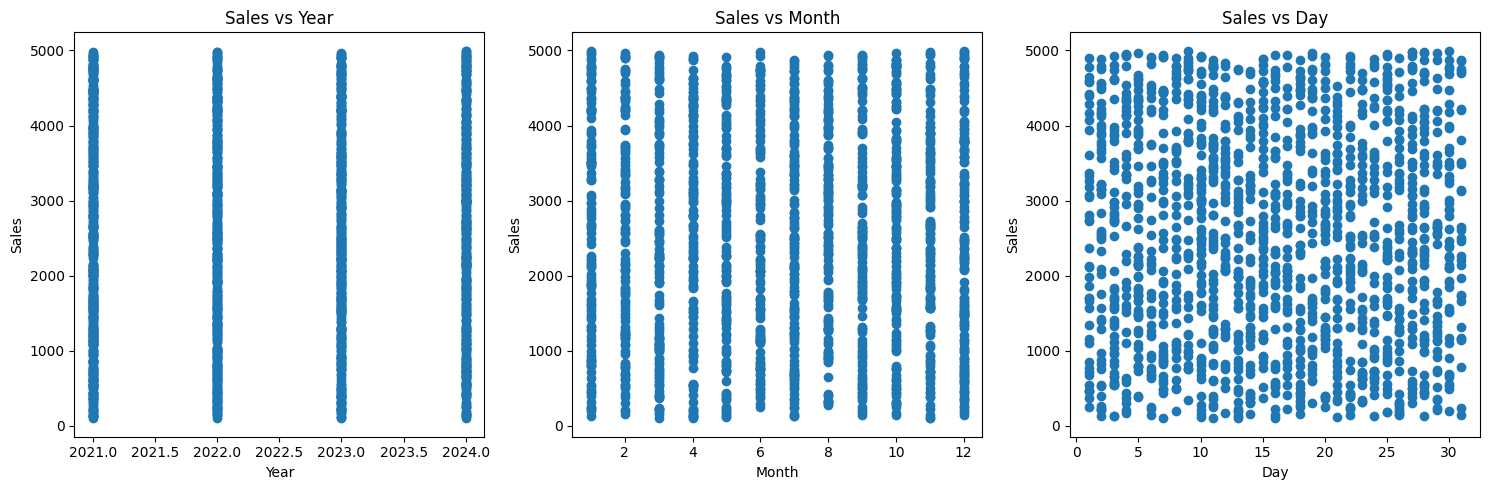

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
axes = axes.flatten()

# Sales vs Profit
axes[0].scatter(df['Year'], df['Sales'])
axes[0].set_title("Sales vs Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Sales")

# Sales vs Quantity
axes[1].scatter(df['Month'], df['Sales'])
axes[1].set_title("Sales vs Month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Sales")

# Sales vs Discount
axes[2].scatter(df['Day'], df['Sales'])
axes[2].set_title("Sales vs Day")
axes[2].set_xlabel("Day")
axes[2].set_ylabel("Sales")

plt.tight_layout()
plt.show()

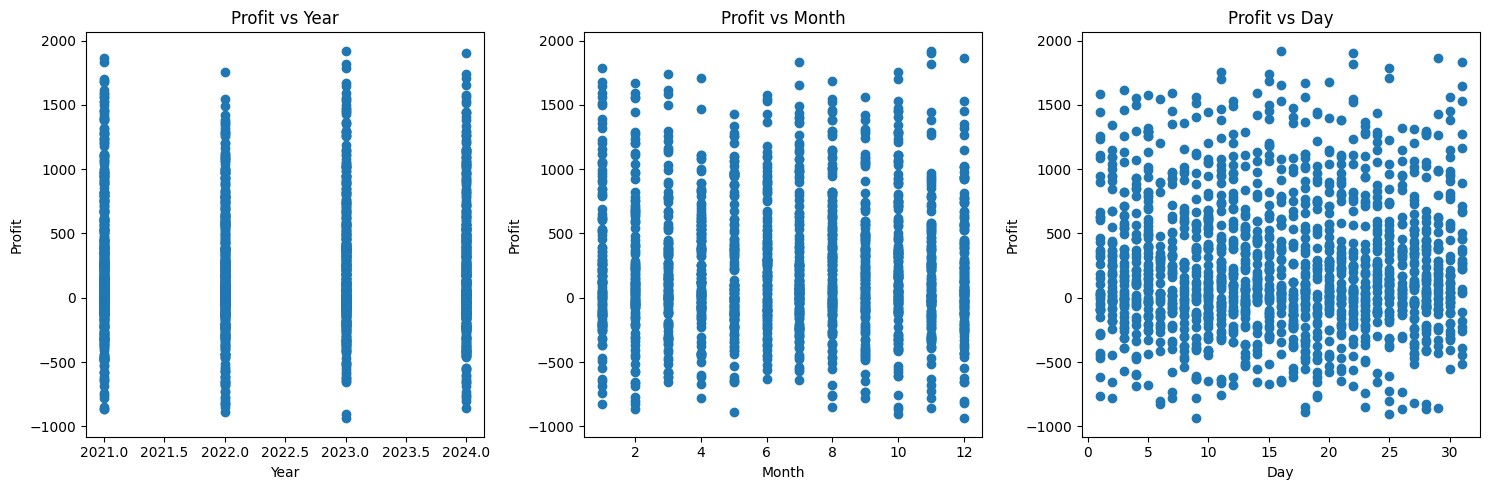

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
axes = axes.flatten()

# Sales vs Profit
axes[0].scatter(df['Year'], df['Profit'])
axes[0].set_title("Profit vs Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Profit")

# Sales vs Quantity
axes[1].scatter(df['Month'], df['Profit'])
axes[1].set_title("Profit vs Month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Profit")

# Sales vs Discount
axes[2].scatter(df['Day'], df['Profit'])
axes[2].set_title("Profit vs Day")
axes[2].set_xlabel("Day")
axes[2].set_ylabel("Profit")

plt.tight_layout()
plt.show()

Order date seems not correlated with Profit and Sales as there is no trend in the scatterplots.

## Part 3 - Predictive Analysis (Machine Learning)

Task 8: Select features and target value

I decided to predict Profit from Sales, which is a more useful information for a company. As the other quantitative features seems not correlated to Profit, I omitted them to avoid noise in the predictions.

In [ ]:
x = df[['Sales']]
y = df['Profit']

Task 9: Split data into training and test sets

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)

Task 10: Build a Linear Regression model

In [ ]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

Task 11: Generate predictions

In [ ]:
lr_predictions = model.predict(x_test)

Task 13: Compare actual vs predicted values for Linear Regression model

In [ ]:
comparison = pd.DataFrame({"Actual":y_test, "Predicted":lr_predictions})
comparison.head()

,Actual,Predicted
1066,362.15,457.145705
1121,-246.33,481.718552
1299,-73.90,488.373970
1236,-72.76,50.585755
784,205.33,357.055085


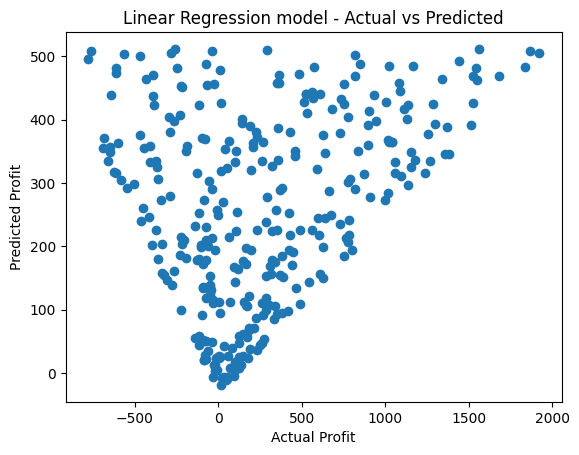

In [ ]:
plt.scatter(y_test, lr_predictions)
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Linear Regression model - Actual vs Predicted")
plt.show()

Task 12: Apply a Decision Tree model

In [ ]:
tree_model = DecisionTreeRegressor()
tree_model.fit(x_train, y_train)

DecisionTreeRegressor()

In [ ]:
tree_predictions = tree_model.predict(x_test)

In [ ]:
comparison = pd.DataFrame({"Actual":y_test, "Predicted":tree_predictions})
comparison.head()

,Actual,Predicted
1066,362.15,1121.11
1121,-246.33,906.32
1299,-73.90,-190.45
1236,-72.76,248.66
784,205.33,1380.99


Task 13: Compare Actual vs Predicted values

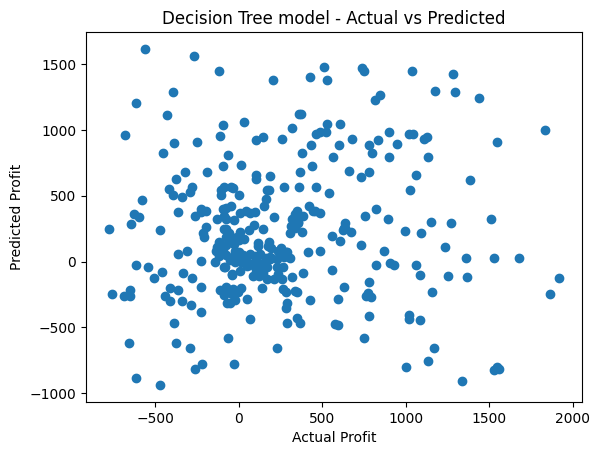

In [ ]:
plt.scatter(y_test, tree_predictions)
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Decision Tree model - Actual vs Predicted")
plt.show()

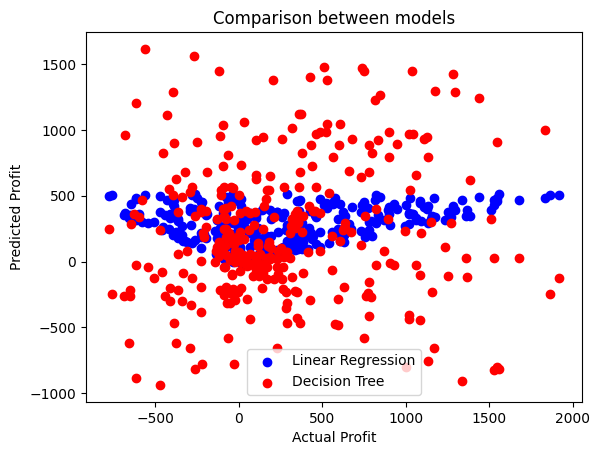

In [ ]:
plt.scatter(y_test, lr_predictions, color="blue", label="Linear Regression")
plt.scatter(y_test, tree_predictions, color="red", label="Decision Tree")
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Comparison between models")
plt.legend()
plt.show()

Linear Regression model seems to predict better the outcomes than the Decision Tree model. Nevertheless, the model need improvements to get more precise predictions.

## Part 4 - Insights & Business Recommendations

- Which category performs best and why?

The category which performs best is sport.

-	Which region shows growth potential?

India shows growth potential as the profits increased in the last years, while in other countries the profits were stable or decreased.

- What factors influence sales the most?

Limiting the analysis to quantitative features and based on the scatterplots above, only the profit influences the sales, as the other variables do not present trends.

Considering the qualitative features, the sales are mostly influenced by country and category, which present trends (as shown in the graphs in Tableau).

-	How accurate is your prediction model?

Both models (Linear Regression and Decision Tree) are not very accurate, as shown in the last scatterplot. More features are needed to improve them.

To improve the models, more variables are needed and, therefore, efforts should be done to include in some ways the regions of the sales and the categories of products.

-	What business recommendations would you give?

I would suggest to avoid too high discounts as they reduce the profit and limit them only to special occasions. Based on recent trends, India shows strong potential for profit growth, making it a promising market for increased investment. USA has great profits, especially for Sport category, making it a valuable market.